In [1]:
# ================================
# 0) 경고/폰트 깔끔 설정 (한 번만)
# ================================
import warnings
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

def setup_plot_env_quiet():
    # (A) pandas groupby.apply 디프리케이션 경고 숨김
    warnings.filterwarnings(
        "ignore",
        message=r"DataFrameGroupBy\.apply operated on the grouping columns",
        category=DeprecationWarning,
    )
    # (B) boxplot용 NaN 경고 숨김(우리가 직접 처리도 함)
    warnings.filterwarnings(
        "ignore",
        message=r"All-NaN slice encountered",
        category=RuntimeWarning,
    )
    # (C) 한글 글리프 경고 숨김(추가로 폰트 설정도 같이 수행)
    warnings.filterwarnings(
        "ignore",
        message=r"Glyph .* missing from font\(s\)",
        category=UserWarning,
    )

    # 한글 가능한 폰트로 시도 (환경에 있는 것만 사용)
    candidates = ["AppleGothic", "NanumGothic", "Malgun Gothic", "Noto Sans CJK KR", "Noto Sans KR"]
    chosen = None
    for name in candidates:
        try:
            path = fm.findfont(name, fallback_to_default=False)
            if path:
                plt.rcParams["font.family"] = name
                chosen = name
                break
        except Exception:
            pass
    # 유니코드 마이너스(−) 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False
    if chosen:
        print(f"[info] font set to: {chosen}")
    else:
        print("[info] Korean font not found; warnings suppressed instead.")

setup_plot_env_quiet()


[info] Korean font not found; warnings suppressed instead.


In [2]:
import numpy as np
import pandas as pd

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

train= pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/CRT/train_part1.parquet' , engine= 'pyarrow')
test = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/CRT/test.parquet' , engine = 'pyarrow')
valid = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/CRT/train_part3.parquet' , engine = 'pyarrow')

Mounted at /content/drive


In [ ]:
import plotly.express as px

test.describe().T\
    .style.bar(subset=['mean'], color=px.colors.qualitative.G10[2])\
    .background_gradient(subset=['std'], cmap='Blues')\
    .background_gradient(subset=['50%'], cmap='BuGn')

,count,mean,std,min,25%,50%,75%,max
l_feat_1,1527298.000000,1.875310,0.330380,1.000000,2.000000,2.000000,2.000000,2.000000
l_feat_2,1526362.000000,1.827422,0.379622,1.000000,2.000000,2.000000,2.000000,2.000000
l_feat_3,1527298.000000,2.454535,0.708983,1.000000,2.000000,3.000000,3.000000,3.000000
l_feat_4,1527298.000000,10.233154,5.744610,1.000000,7.000000,8.000000,14.000000,26.000000
l_feat_5,1527298.000000,503.176056,403.495056,1.000000,113.000000,457.000000,965.000000,1166.000000
l_feat_6,1527298.000000,429.895569,325.368378,1.000000,161.000000,385.000000,730.000000,988.000000
l_feat_7,1527298.000000,165.016068,91.591270,1.000000,94.000000,152.000000,212.000000,329.000000
l_feat_8,1526362.000000,1.993872,0.077834,1.000000,2.000000,2.000000,2.000000,2.000000
l_feat_9,1527298.000000,243.005814,153.111557,1.000000,113.000000,235.000000,351.000000,505.000000
l_feat_10,1527298.000000,119.424805,67.771584,1.000000,83.000000,115.000000,162.000000,277.000000


In [ ]:
def summary(df):
    sum = pd.DataFrame(test.dtypes, columns=['dtypes'])
    sum['결측치 개수'] = df.isna().sum()
    sum['결측치 비율'] = (df.isna().sum())/len(df)
    sum['고유값 개수'] = df.nunique().values
    sum['데이터 개수'] = df.count().values


    return sum

summary(test).style.background_gradient(cmap='Blues')

,dtypes,결측치 개수,결측치 비율,고유값 개수,데이터 개수
ID,object,0,0.000000,1527298,1527298
gender,object,936,0.000613,2,1526362
age_group,object,936,0.000613,8,1526362
inventory_id,object,0,0.000000,18,1527298
day_of_week,object,0,0.000000,1,1527298
hour,object,0,0.000000,24,1527298
seq,object,0,0.000000,1018685,1527298
l_feat_1,float32,0,0.000000,2,1527298
l_feat_2,float32,936,0.000613,2,1526362
l_feat_3,float32,0,0.000000,3,1527298


In [ ]:
cols_to_convert = [c for c in test.columns if c not in ['seq' ,'ID']]
test[cols_to_convert]  = test[cols_to_convert].astype("float32")

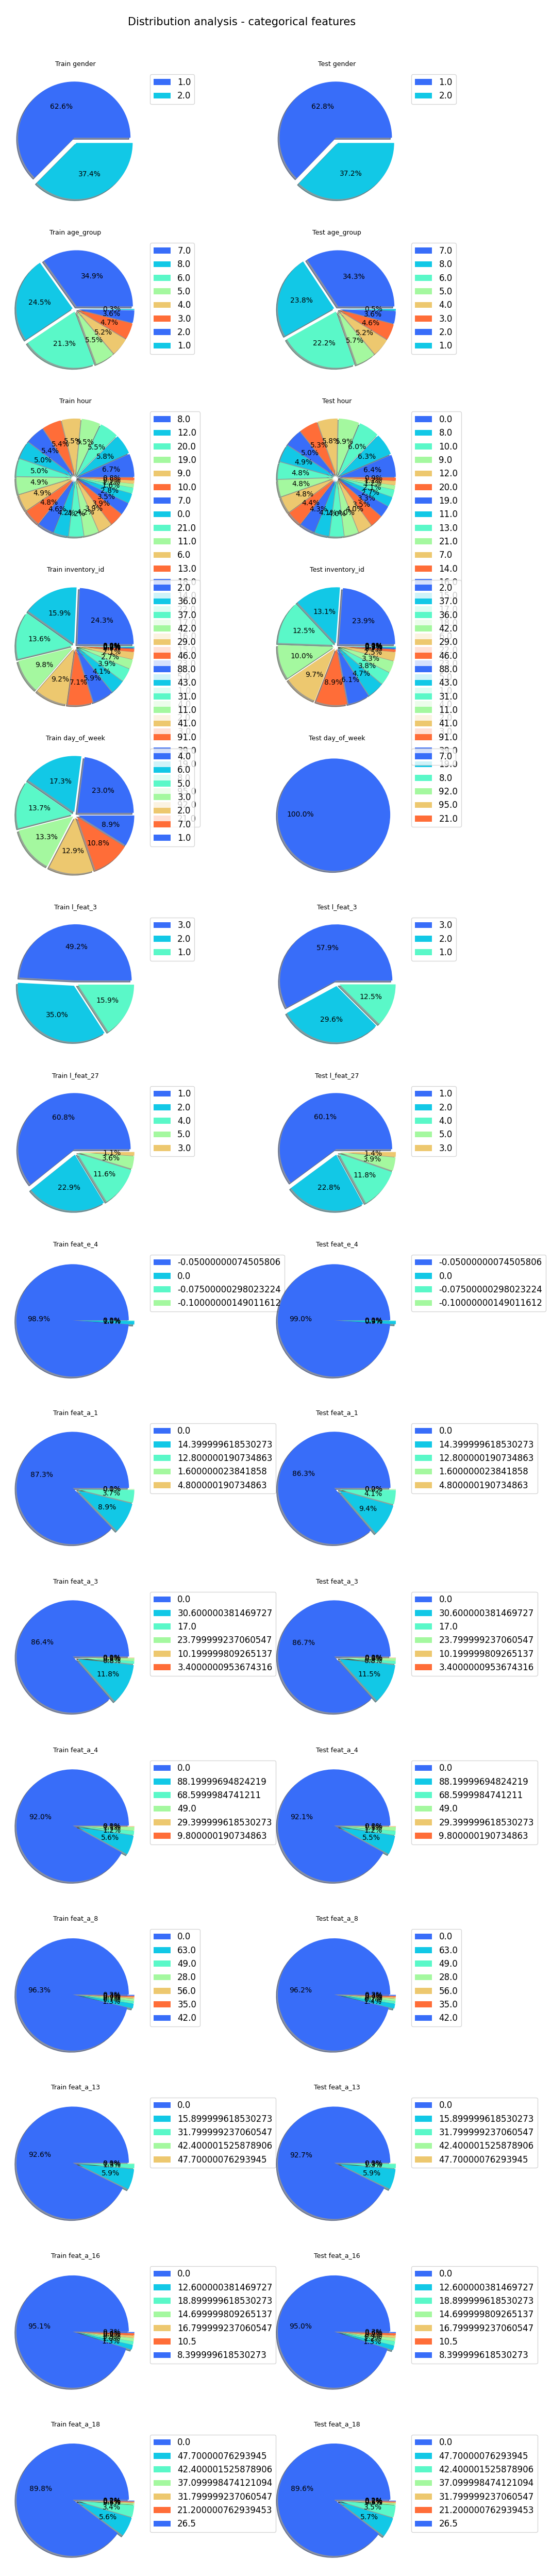

In [ ]:
import seaborn as sns
sns.set_palette('rainbow')

sparse= ['gender' ,'age_group','hour','inventory_id', 'day_of_week',
         'l_feat_3',
         'l_feat_27',
         'feat_e_4',
         'feat_a_1',
         'feat_a_3',
         'feat_a_4',
         'feat_a_8',
         'feat_a_13',
         'feat_a_16',
         'feat_a_18']


exclude = {'clicked','ID','seq'}

cols = [c for c in sparse if c in train.columns and c in test.columns and c not in exclude]


df = pd.concat([train[cols].assign(Source = 'train'),
                test[cols].assign(Source = 'test')],
               axis=0, ignore_index = True)

fig, axes = plt.subplots(len(cols), 2 ,figsize = (12, len(cols) * 4.2))

for i,col in enumerate(cols):
    train_dist = df.loc[df.Source == 'train', [col]].value_counts()
    test_dist = df.loc[df.Source == 'test', [col]].value_counts()

    ax = axes[i,0]
    ax.pie(train_dist, shadow=True, explode=[.05]*len(train_dist), autopct='%.1f%%')
    ax.legend([category[0] for category in train_dist.index], loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    ax.set(xlabel = '', ylabel = '')
    ax.set_title(f'Train {col}',fontsize = 9)

    ax = axes[i,1]
    ax.pie(test_dist, shadow=True, explode=[.05]*len(test_dist), autopct='%.1f%%')
    ax.legend([category[0] for category in test_dist.index], loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    ax.set(xlabel = '', ylabel = '')
    ax.set_title(f'Test {col}',fontsize = 9)


plt.suptitle(f"\nDistribution analysis - categorical features\n",fontsize = 15, y = 0.9, x = 0.57)
plt.show()

Text(0.5, 1.0, 'clicked')

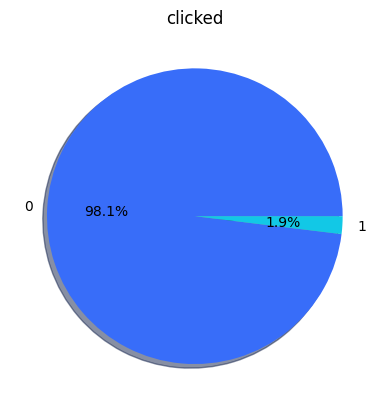

In [ ]:
plt.pie(train['clicked'].value_counts(), labels=train['clicked'].value_counts().index, autopct='%.1f%%', shadow = True)
plt.title('clicked')


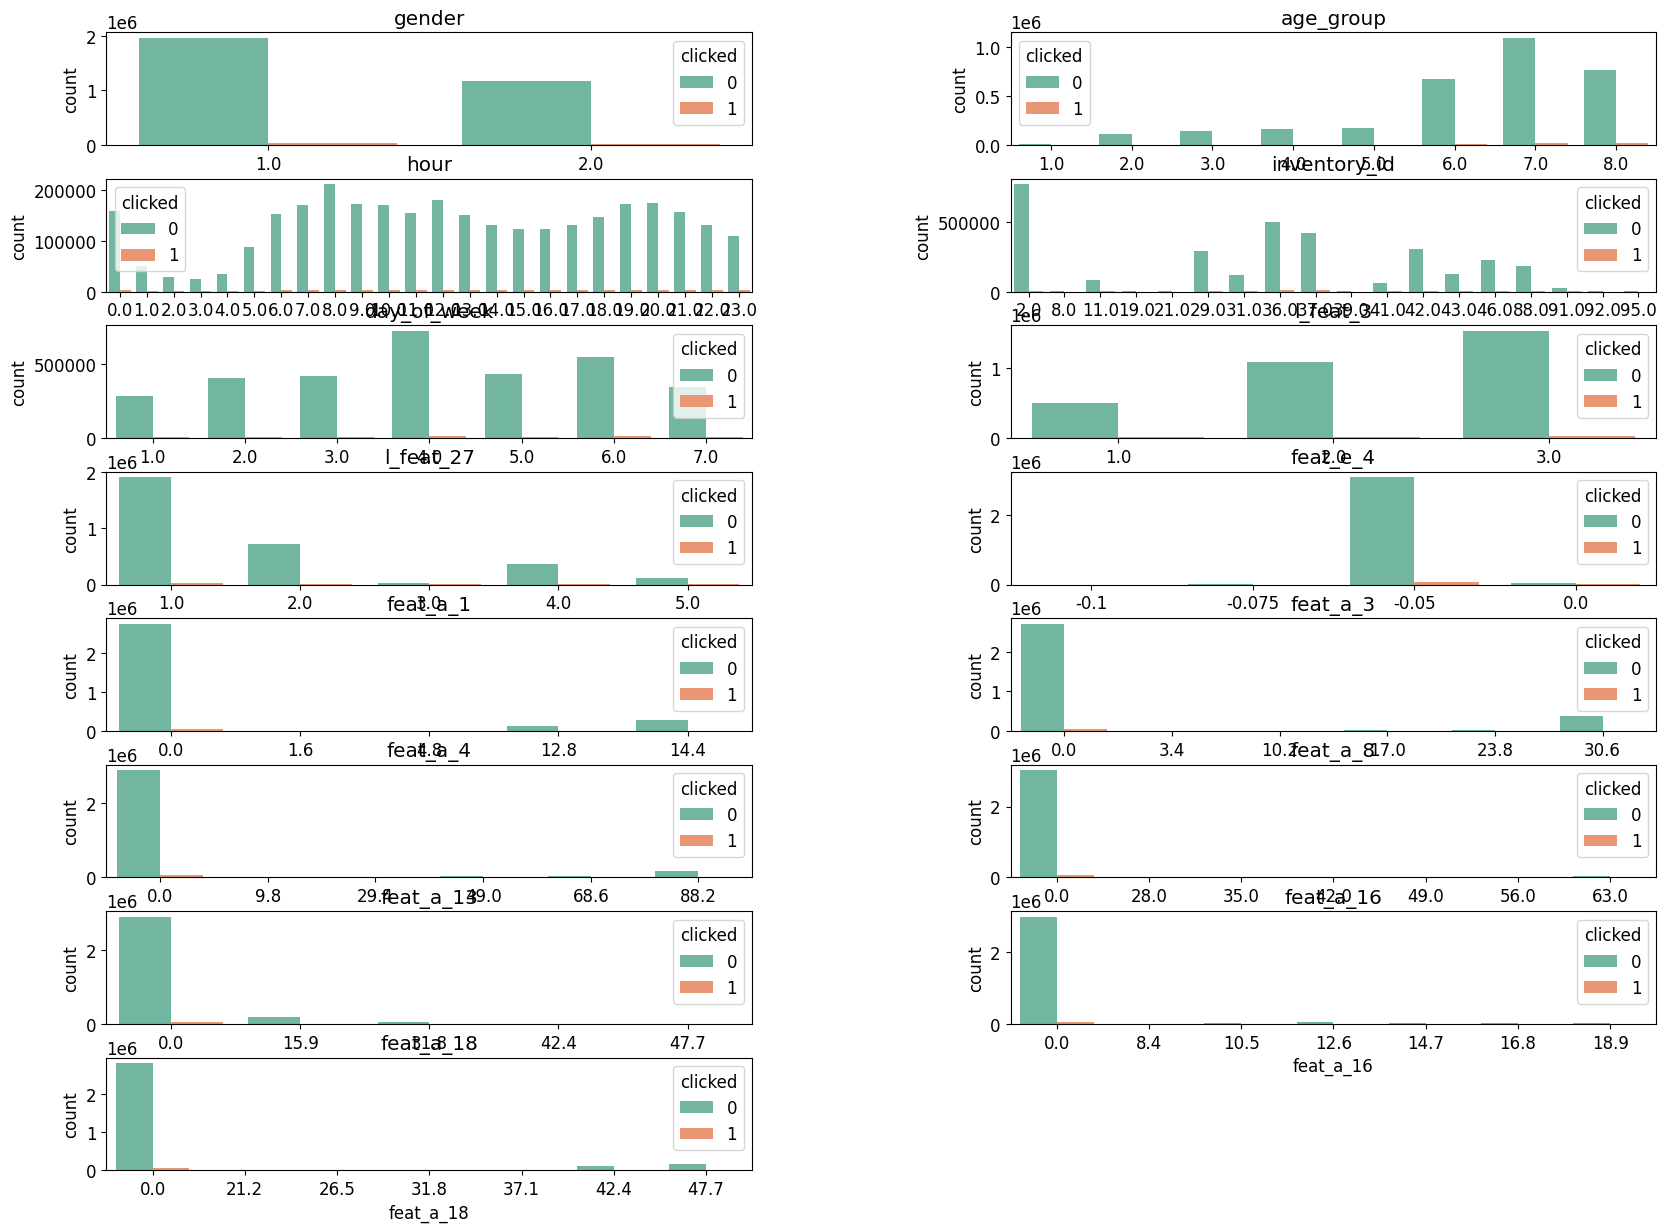

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

mpl.rc('font' , size = 12)
grid = gridspec.GridSpec(16,2)
plt.figure(figsize = (20,30))  # 전체 Figure 크기 설정
plt.subplots_adjust(wspace = 0.4, hspace = 0.3) # 서브플롯 간 좌우/상하 여백 설정

#서브플롯 그리기

bin_features =  ['gender' ,'age_group','hour','inventory_id', 'day_of_week',
         'l_feat_3',
         'l_feat_27',
         'feat_e_4',
         'feat_a_1',
         'feat_a_3',
         'feat_a_4',
         'feat_a_8',
         'feat_a_13',
         'feat_a_16',
         'feat_a_18']  # 피처 목록

def write_percent(ax, total_size):
  for patch in ax.patches:
      width, height = patch.get_width(), patch.get_height() # 도형 높이, 도형 너비

for idx, feature in enumerate(bin_features):
  ax = plt.subplot(grid[idx])

  sns.countplot(x = train[feature],
              data = train,
              hue = train['clicked'],
              palette = 'Set2',
              ax=ax
              )

  ax.set_title(f'{feature}')
  write_percent(ax, len(train))  # 비율 표시


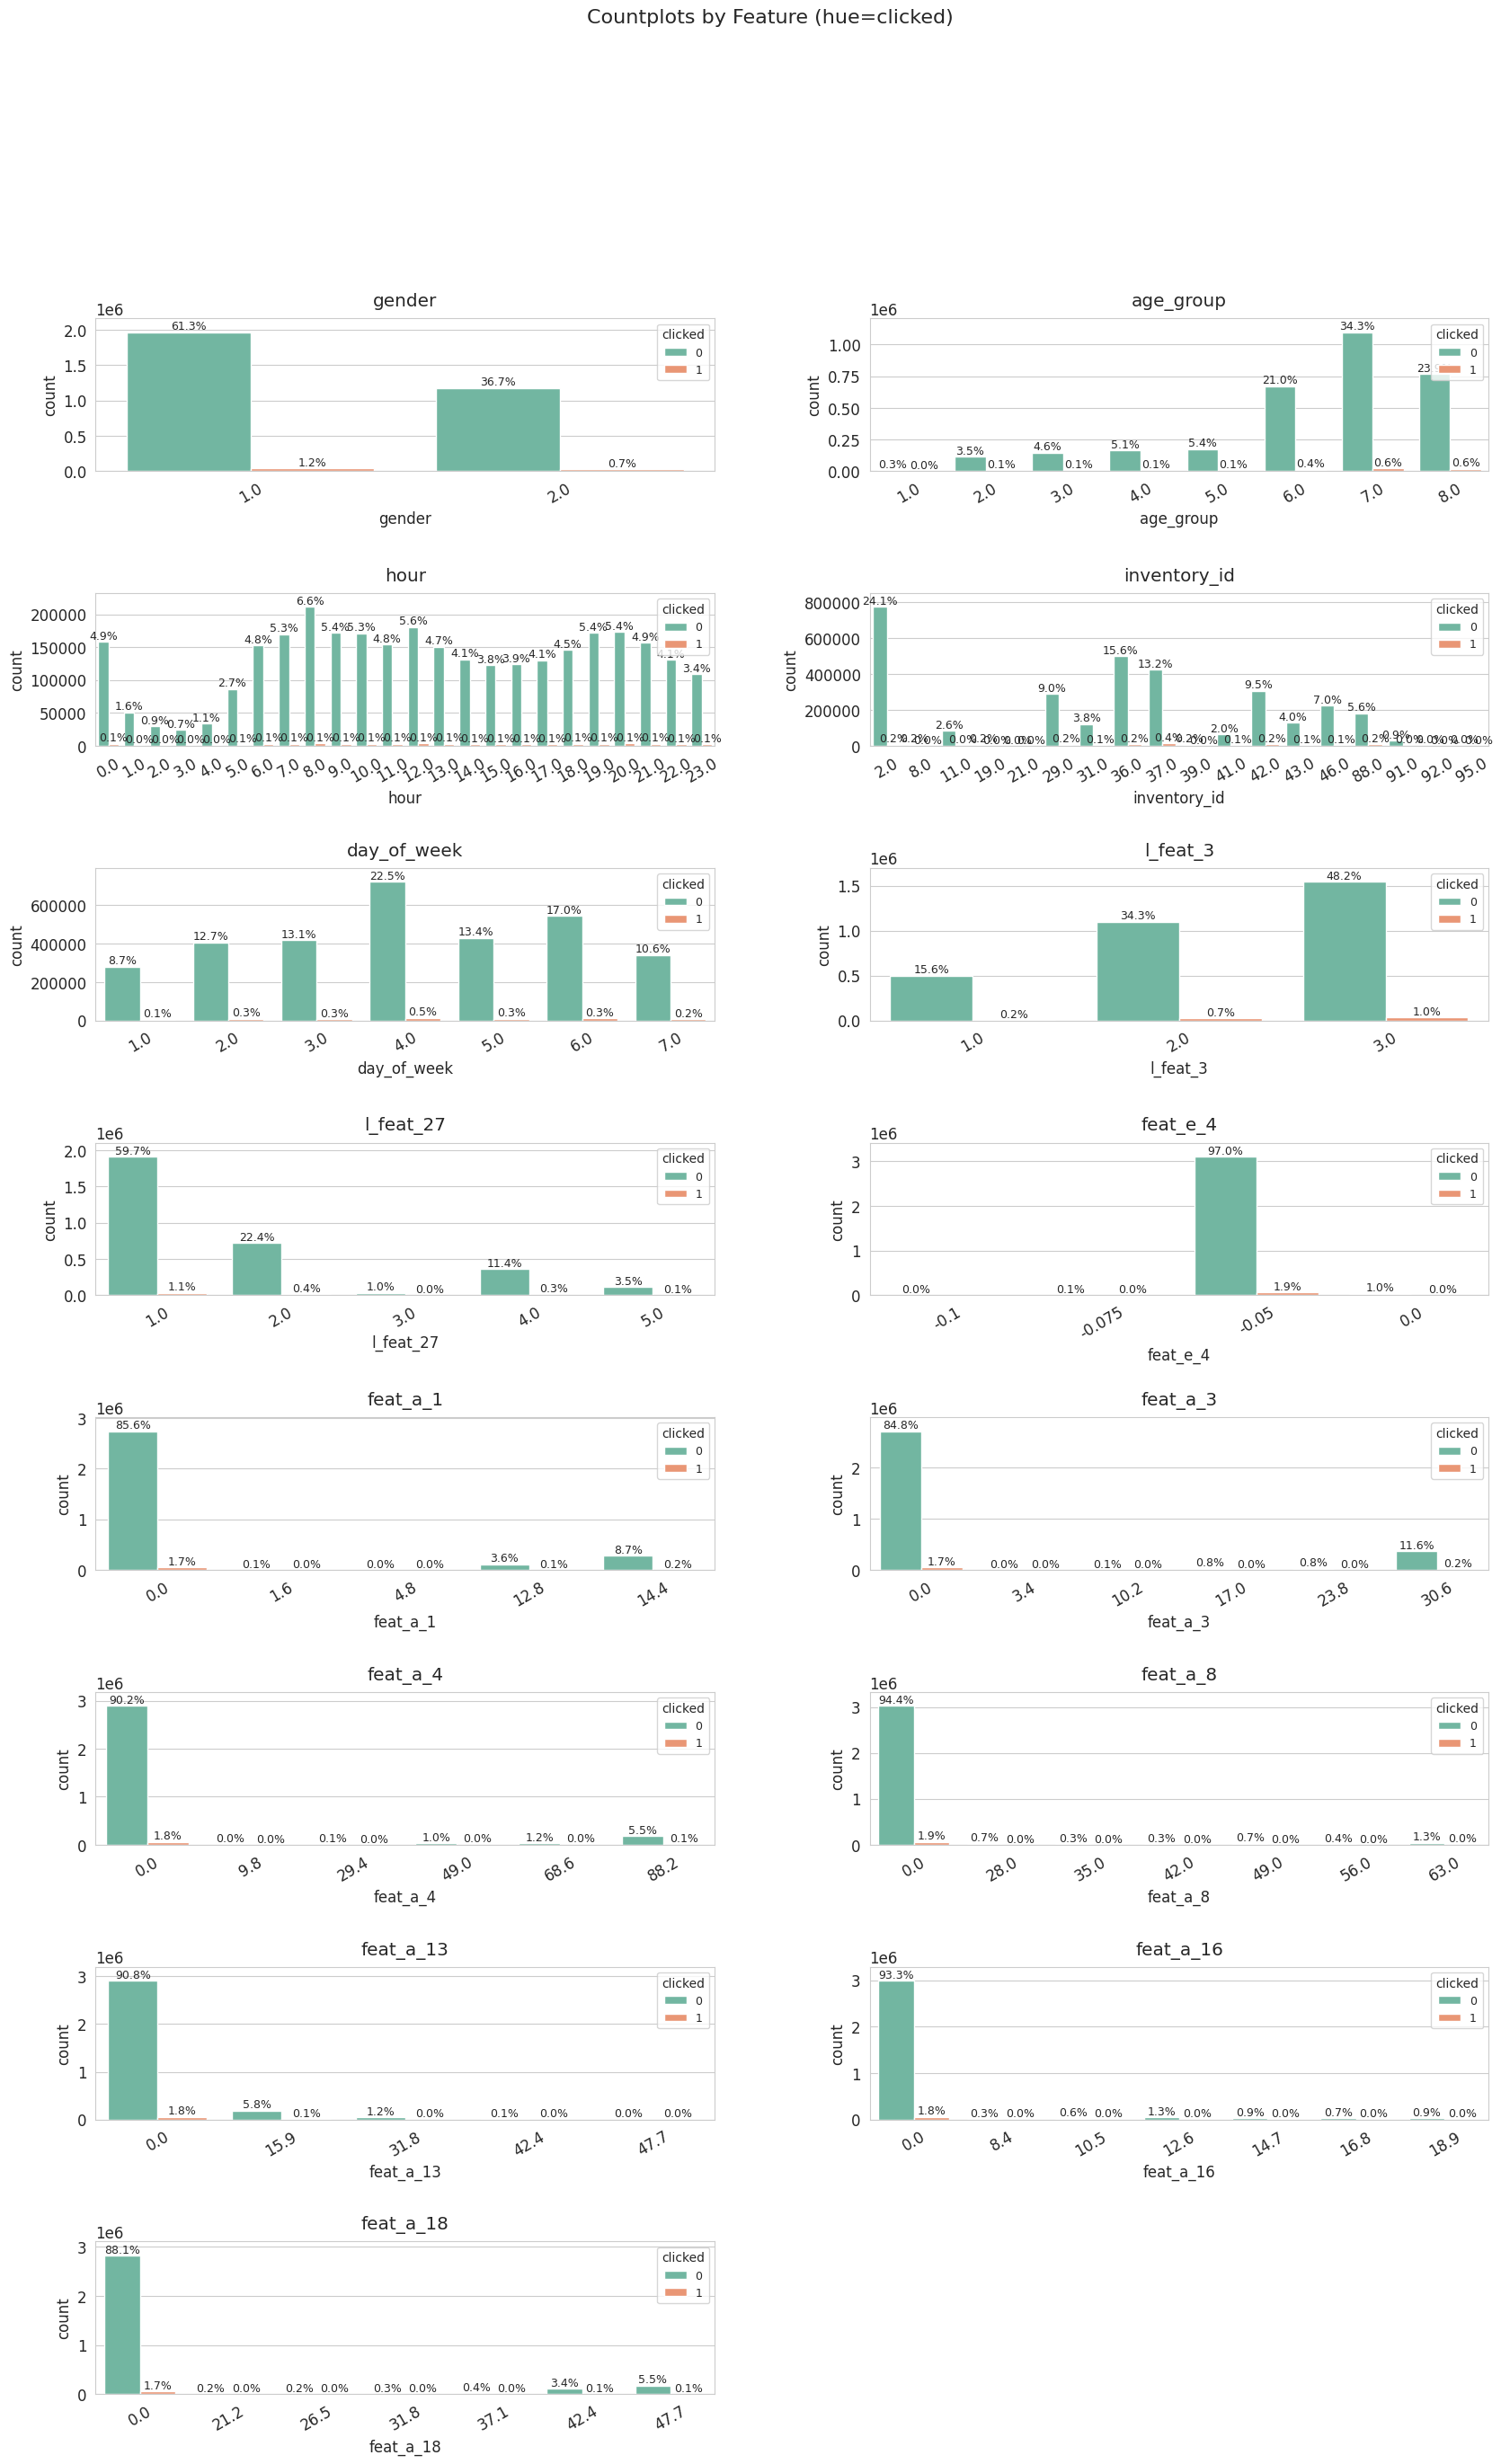

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# 기본 스타일 & 폰트 크기
# ------------------------------
mpl.rc('font', size=12)
sns.set_style("whitegrid")

# ------------------------------
# 피처 목록 (원본 그대로)
# ------------------------------
bin_features = [
    'gender', 'age_group', 'hour', 'inventory_id', 'day_of_week',
    'l_feat_3', 'l_feat_27', 'feat_e_4', 'feat_a_1', 'feat_a_3',
    'feat_a_4', 'feat_a_8', 'feat_a_13', 'feat_a_16', 'feat_a_18'
]

# ------------------------------
# 보조 함수: 막대 위 퍼센트 라벨
# (전체 데이터 대비 비율 표시)
# ------------------------------
def write_percent(ax, total_size):
    # 패치가 없을 때(데이터 없는 축 등) 안전 처리
    if not hasattr(ax, "patches"):
        return
    for p in ax.patches:
        height = p.get_height()
        # 높이가 0인 막대는 스킵
        if height <= 0:
            continue
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height,
            f'{height / total_size:.1%}',
            ha='center', va='bottom', fontsize=9, rotation=0
        )

# ------------------------------
# Figure & GridSpec 설정
# (오타 수정: (20, 30), 충분한 세로 크기)
# ------------------------------
fig = plt.figure(figsize=(20, 30))
grid = gridspec.GridSpec(
    nrows=8, ncols=2, figure=fig,
    wspace=0.25,  # 좌우 간격
    hspace=0.8    # 상하 간격 (제목/범례 겹침 방지)
)

# ------------------------------
# 서브플롯 루프
# ------------------------------
total_size = len(train)
for idx, feature in enumerate(bin_features):
    ax = fig.add_subplot(grid[idx])

    # seaborn.countplot 최신 시그니처: data=... + 문자열 컬럼명 권장
    sns.countplot(
        data=train,
        x=feature,
        hue='clicked',
        palette='Set2',
        ax=ax
    )

    # 제목
    ax.set_title(f'{feature}', pad=10)

    # x tick 라벨 겹침 방지
    ax.tick_params(axis='x', labelrotation=30)
    # 너무 긴 라벨이면 자동 줄바꿈(간단히 회전으로 처리, 더 필요하면 textwrap 사용)

    # 범례 위치/크기(겹치지 않도록 오른쪽 위)
    leg = ax.legend(title='clicked', loc='upper right', fontsize=9, title_fontsize=10)
    # 범례가 가끔 그래프 영역 가리면, 아래처럼 밖으로 뺄 수도 있음
    # ax.legend(title='clicked', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

    # 퍼센트 라벨(전체 대비 비율)
    write_percent(ax, total_size)

    # 상단 여백 약간
    ax.margins(y=0.10)

# 빈 칸(총 16칸 중 15개 사용) 하나는 비워둠
plt.suptitle('Countplots by Feature (hue=clicked)', fontsize=16, y=0.995)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

def plot_target_ratio_by_features(train, features, size = (12,18)):

  plt.rc('font' , size = 9)
  plt.figure(figsize = size) # 전체 Figure 크기 설정

  # 특성 개수를 기반으로 필요한 행 수 계산
  num_rows = (len(features) + 1) // 2  # 특성 개수가 홀수인 경우 처리하기 위해 +1

  # 모든 특성을 수용하도록 GridSpec 업데이트
  grid = gridspec.GridSpec(num_rows, 2) # 서브 플롯 배치

  plt.subplots_adjust(wspace = 0.4, hspace = 0.3) # 서브플롯 간 좌우/상하 여백 설정

  for idx, feature in enumerate(features):
    ax = plt.subplot(grid[idx])

    # ax축에 고윳값별 타깃값 1의 비율을 막대그래프로 그리기
    sns.barplot(x = train[feature],
                y='clicked',
                data = train,
                palette = 'Set2',
                ax=ax
                )
    ax.invert_yaxis()

/tmp/ipython-input-2573031673.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = train[feature],
/tmp/ipython-input-2573031673.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = train[feature],
/tmp/ipython-input-2573031673.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = train[feature],
/tmp/ipython-input-2573031673.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 

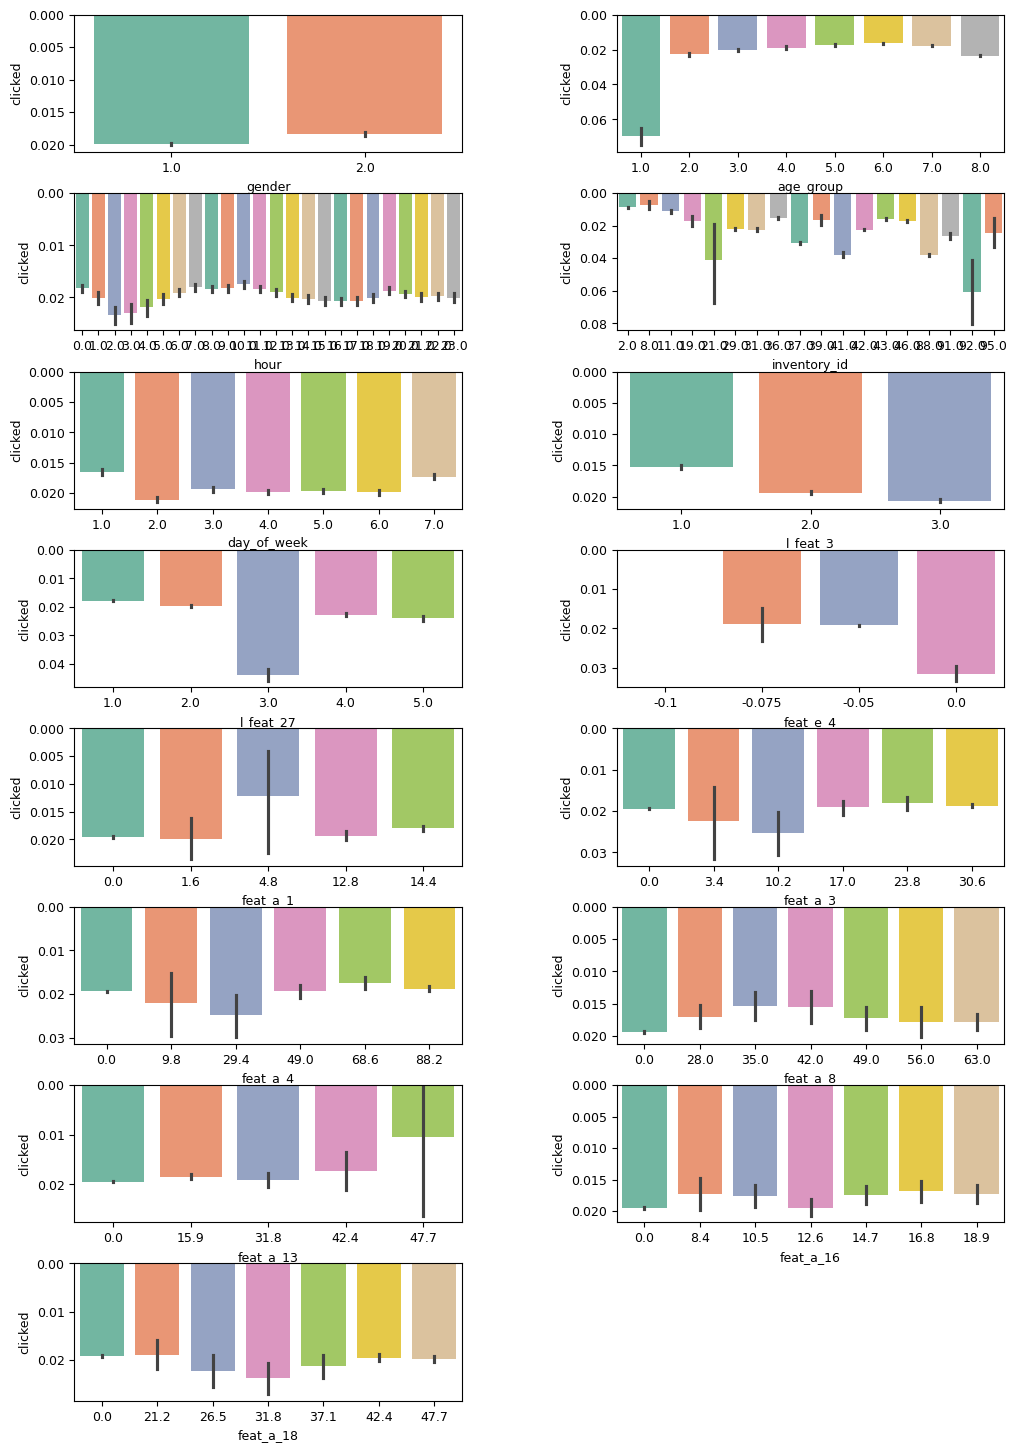

In [ ]:
nom_features =  ['gender' ,'age_group','hour','inventory_id', 'day_of_week',
         'l_feat_3',
         'l_feat_27',
         'feat_e_4',
         'feat_a_1',
         'feat_a_3',
         'feat_a_4',
         'feat_a_8',
         'feat_a_13',
         'feat_a_16',
         'feat_a_18']

plot_target_ratio_by_features(train , nom_features , size = (12,18))

1. 기본 빈도 히스토그램 / 로그 스케일 플롯

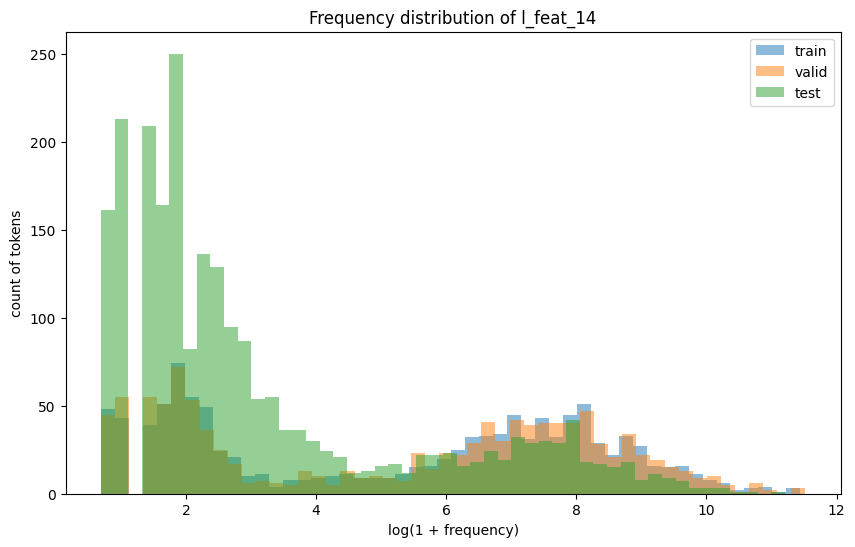

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

col = "l_feat_14"  # 타겟 feature

# 빈도 계산 함수
def get_freq_series(df, col):
    c = Counter(df[col])
    freq = pd.Series(list(c.values()))
    return freq.sort_values(ascending=False).reset_index(drop=True)

freq_train = get_freq_series(train, col)
freq_valid = get_freq_series(valid, col)
freq_test  = get_freq_series(test,  col)

plt.figure(figsize=(10,6))
plt.hist(np.log1p(freq_train), bins=50, alpha=0.5, label='train')
plt.hist(np.log1p(freq_valid), bins=50, alpha=0.5, label='valid')
plt.hist(np.log1p(freq_test),  bins=50, alpha=0.5, label='test')
plt.xlabel('log(1 + frequency)')
plt.ylabel('count of tokens')
plt.title(f'Frequency distribution of {col}')
plt.legend()
plt.show()


train/valid 분포는 비교적 비슷하지만,test 분포에서 log(1+frequency) 값이 낮은 영역(빈도 1~10 근처) 에 토큰이 압도적으로 많음.

특히 왼쪽 구간(1~3 로그 구간)에 test만 솟아 있는 건,train에선 잘 안 보이던 희귀 광고(rare ad set)가 test에 대거 들어와 있다.

2. 커버리지 곡선 (Cumulative Coverage Plot)

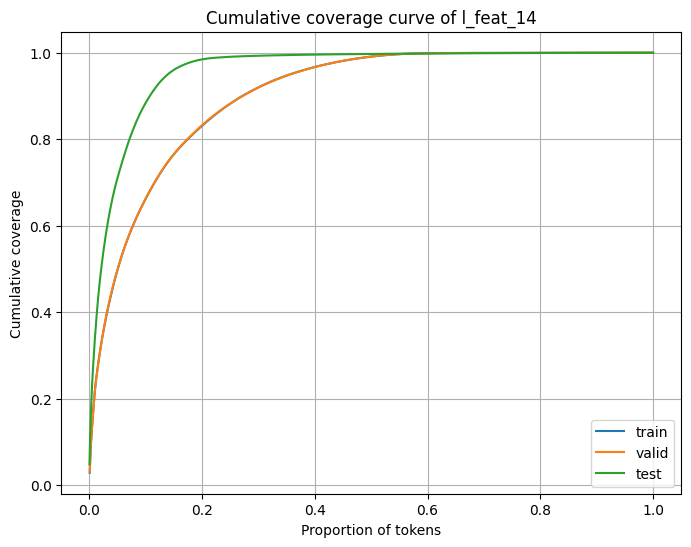

In [ ]:
def plot_coverage(freq_series, label):
    freq = freq_series.sort_values(ascending=False).to_numpy()
    coverage = np.cumsum(freq) / np.sum(freq)
    plt.plot(np.arange(1, len(freq)+1)/len(freq), coverage, label=label)

plt.figure(figsize=(8,6))
plot_coverage(freq_train, 'train')
plot_coverage(freq_valid, 'valid')
plot_coverage(freq_test, 'test')
plt.xlabel('Proportion of tokens')
plt.ylabel('Cumulative coverage')
plt.title(f'Cumulative coverage curve of {col}')
plt.legend()
plt.grid(True)
plt.show()


>
    많이 등장하는 고유값(토큰) 들은 그대로 임베딩 테이블에서 학습하고,
    나머지 희귀 토큰들은 전부 UNK(unknown) 하나로 묶어서 하나의 임베딩만 학습하게 만드는 전략

> trian / valid는 0.2-0.4 지점에서 토큰(l_feat_14의 고유값)이 90% 이상의 빈도를 차지

> test는 0.05 이내에 거의 90% 이상에 수렴한다. -> 빈도에 대해 긴 tail 형태

따라서 상위 95% coverage만 남기고 나머지를 UNK로 보내도 대부분의 예측력을 유지할 수 있음.

3. 공통 토큰 비율 비교 (Overlap Check)
-  Cold-start rate 분석

In [ ]:
train_tokens = set(train[col])
valid_tokens = set(valid[col])
test_tokens  = set(test[col])

cold_valid = len(valid_tokens - train_tokens) / len(valid_tokens) * 100
cold_test  = len(test_tokens - train_tokens) / len(test_tokens) * 100

print(f"Valid cold-start token rate: {cold_valid:.2f}%")
print(f"Test cold-start token rate: {cold_test:.2f}%")


Valid cold-start token rate: 2.22%
Test cold-start token rate: 83.15%


test에서 무려 83%의 토큰이 train에 등장하지 않음 → 전형적인 cold ad set 문제.(모델이 학습 중에 본 적이 없는 토큰(고유값)이, 예측(서빙) 시점에 처음 등장하는 상황)

이 상태에선 아무리 모델을 잘 학습해도, test에서 83%의 토큰이 embedding에서 UNK나 무작위로 처리되므로 성능 상한이 낮아짐.

inventory_id

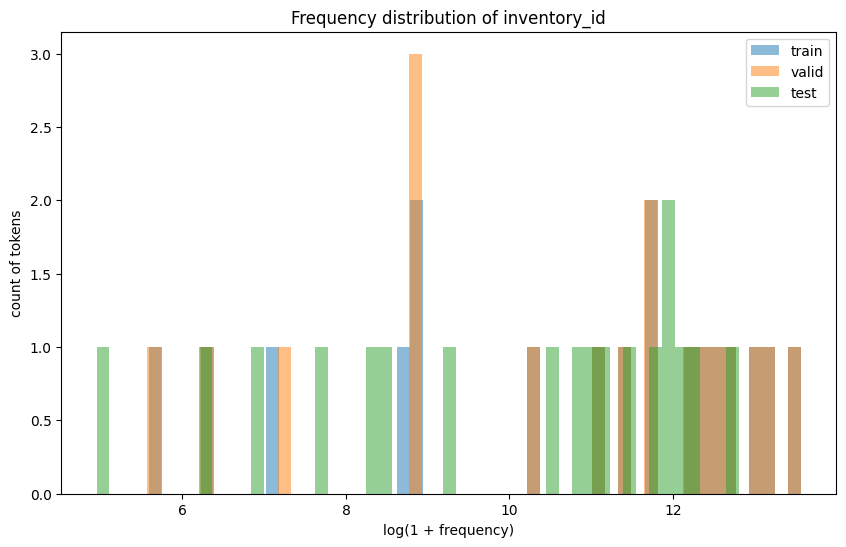

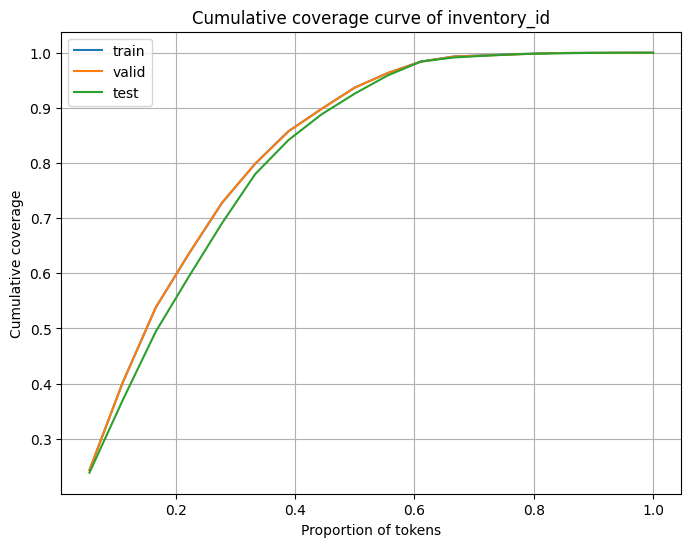

[inventory_id] Cold-start token rate:
  - Valid: 0.00%
  - Test : 100.00%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# ===============================
# 시각화 함수 정의
# ===============================
def get_freq_series(df, col):
    c = Counter(df[col])
    freq = pd.Series(list(c.values()))
    return freq.sort_values(ascending=False).reset_index(drop=True)

def plot_freq_histogram(train, valid, test, col):
    freq_train = get_freq_series(train, col)
    freq_valid = get_freq_series(valid, col)
    freq_test  = get_freq_series(test,  col)

    plt.figure(figsize=(10,6))
    plt.hist(np.log1p(freq_train), bins=50, alpha=0.5, label='train')
    plt.hist(np.log1p(freq_valid), bins=50, alpha=0.5, label='valid')
    plt.hist(np.log1p(freq_test),  bins=50, alpha=0.5, label='test')
    plt.xlabel('log(1 + frequency)')
    plt.ylabel('count of tokens')
    plt.title(f'Frequency distribution of {col}')
    plt.legend()
    plt.show()

def plot_coverage_curve(train, valid, test, col):
    def coverage(freq_series):
        freq = freq_series.sort_values(ascending=False).to_numpy()
        return np.cumsum(freq) / np.sum(freq)

    freq_train = get_freq_series(train, col)
    freq_valid = get_freq_series(valid, col)
    freq_test  = get_freq_series(test,  col)

    plt.figure(figsize=(8,6))
    plt.plot(np.arange(1, len(freq_train)+1)/len(freq_train), coverage(freq_train), label='train')
    plt.plot(np.arange(1, len(freq_valid)+1)/len(freq_valid), coverage(freq_valid), label='valid')
    plt.plot(np.arange(1, len(freq_test)+1)/len(freq_test), coverage(freq_test), label='test')
    plt.xlabel('Proportion of tokens')
    plt.ylabel('Cumulative coverage')
    plt.title(f'Cumulative coverage curve of {col}')
    plt.legend()
    plt.grid(True)
    plt.show()

def print_cold_rate(train, valid, test, col):
    train_tokens = set(train[col])
    valid_tokens = set(valid[col])
    test_tokens  = set(test[col])

    cold_valid = len(valid_tokens - train_tokens) / len(valid_tokens) * 100
    cold_test  = len(test_tokens - train_tokens) / len(test_tokens) * 100

    print(f"[{col}] Cold-start token rate:")
    print(f"  - Valid: {cold_valid:.2f}%")
    print(f"  - Test : {cold_test:.2f}%")

# ===============================
# inventory_id 분석 실행
# ===============================
target_col = "inventory_id"
plot_freq_histogram(train, valid, test, target_col)
plot_coverage_curve(train, valid, test, target_col)
print_cold_rate(train, valid, test, target_col)


inventory_id는 cold-start가 100%이기 때문에 tail cutoff로 해결할 수 있는 피처가 아님.

사실상 test에선 UNK 하나만 쓰게 되는 상황이라, 이 피처는 본질적으로 예측에 기여할 수 있는 정보가 거의 없다.

대신 다른 피처와의 interaction 혹은 아예 제거/보조 신호 전환을 고려해야 한다.